## Step 1: Research Question

### Research Question

Can we classify whether a PS5 game has a high rating or low rating using release year, release month, total ratings count, and age restriction?

### Objective

The goal of this study is to classify PS5 games using the K-Nearest Neighbors algorithm.

### Variables

Target Variable:
- High_Rating

Predictor Variables:
- releaseYear
- releaseMonth
- starRating/totalRatingsCount
- isAgeRestricted|

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [5]:
df = pd.read_csv("ps5.csv")
df.head()

,url,id,publisherName,releaseDate,name,isAgeRestricted,activeCtaId,starRating/averageRating,starRating/totalRatingsCount
0,https://store.playstation.com/en-us/product/UP...,UP0101-PPSA19225_00-0159266583099383,"Konami Digital Entertainment, Inc.",2024-03-28T04:00:00Z,Felix the Cat,False,PREORDER:BUY_NOW:UP0101-PPSA19225_00-015926658...,5.00,1
1,https://store.playstation.com/en-us/product/UP...,UP2565-PPSA04379_00-0242096879154610,astragon Entertainment GmbH,2024-04-04T15:00:00Z,Construction Simulator - Gold Edition,False,PREORDER:BUY_NOW:UP2565-PPSA04379_00-024209687...,3.55,1526
2,https://store.playstation.com/en-us/product/UP...,UP4040-PPSA04721_00-HUNDREDHEROESDLX,505 Games,2024-04-21T13:00:00Z,Eiyuden Chronicle: Hundred Heroes - Digital De...,False,PREORDER:BUY_NOW:UP4040-PPSA04721_00-HUNDREDHE...,4.79,29
3,https://store.playstation.com/en-us/product/UP...,UP4040-PPSA04721_00-EIYUDENHEROESPS5,505 Games,2024-04-23T13:00:00Z,Eiyuden Chronicle: Hundred Heroes,False,PREORDER:BUY_NOW:UP4040-PPSA04721_00-EIYUDENHE...,4.79,29
4,https://store.playstation.com/en-us/product/UP...,UP9000-PPSA13196_00-STELLARBLADEDDE0,Sony Interactive Entertainment,2024-04-26T04:00:00Z,Stellar Blade™ Digital Deluxe Edition,False,PREORDER:BUY_NOW:UP9000-PPSA13196_00-STELLARBL...,0.00,0


## Step 2: Data Understanding

We check the number of rows and columns, dataset information, summary statistics, and missing values.

In [6]:
df.shape

(2001, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2001 entries, 0 to 2000
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   url                           2001 non-null   str    
 1   id                            2001 non-null   str    
 2   publisherName                 2000 non-null   str    
 3   releaseDate                   2001 non-null   str    
 4   name                          2001 non-null   str    
 5   isAgeRestricted               2001 non-null   bool   
 6   activeCtaId                   2001 non-null   str    
 7   starRating/averageRating      2001 non-null   float64
 8   starRating/totalRatingsCount  2001 non-null   int64  
dtypes: bool(1), float64(1), int64(1), str(6)
memory usage: 127.1 KB


In [8]:
df.describe()

,starRating/averageRating,starRating/totalRatingsCount
count,2001.000000,2.001000e+03
mean,3.934218,1.364253e+04
std,0.882803,2.587326e+05
min,0.000000,0.000000e+00
25%,3.640000,1.700000e+01
50%,4.160000,7.300000e+01
75%,4.500000,5.010000e+02
max,5.000000,6.661979e+06


In [9]:
df.isnull().sum()

url                             0
id                              0
publisherName                   1
releaseDate                     0
name                            0
isAgeRestricted                 0
activeCtaId                     0
starRating/averageRating        0
starRating/totalRatingsCount    0
dtype: int64

## Step 3: Data Preprocessing

The releaseDate column will be converted into date format.

The release year and release month will be extracted.

The isAgeRestricted column will be converted into numeric values.

A new target variable named High_Rating will be created.

In [11]:
df["releaseDate"] = pd.to_datetime(df["releaseDate"])

df["releaseYear"] = df["releaseDate"].dt.year
df["releaseMonth"] = df["releaseDate"].dt.month

In [12]:
df["isAgeRestricted"] = df["isAgeRestricted"].astype(int)

In [13]:
df["High_Rating"] = (df["starRating/averageRating"] >= 4).astype(int)

df.head()

,url,id,publisherName,releaseDate,name,isAgeRestricted,activeCtaId,starRating/averageRating,starRating/totalRatingsCount,releaseYear,releaseMonth,High_Rating
0,https://store.playstation.com/en-us/product/UP...,UP0101-PPSA19225_00-0159266583099383,"Konami Digital Entertainment, Inc.",2024-03-28 04:00:00+00:00,Felix the Cat,0,PREORDER:BUY_NOW:UP0101-PPSA19225_00-015926658...,5.00,1,2024,3,1
1,https://store.playstation.com/en-us/product/UP...,UP2565-PPSA04379_00-0242096879154610,astragon Entertainment GmbH,2024-04-04 15:00:00+00:00,Construction Simulator - Gold Edition,0,PREORDER:BUY_NOW:UP2565-PPSA04379_00-024209687...,3.55,1526,2024,4,0
2,https://store.playstation.com/en-us/product/UP...,UP4040-PPSA04721_00-HUNDREDHEROESDLX,505 Games,2024-04-21 13:00:00+00:00,Eiyuden Chronicle: Hundred Heroes - Digital De...,0,PREORDER:BUY_NOW:UP4040-PPSA04721_00-HUNDREDHE...,4.79,29,2024,4,1
3,https://store.playstation.com/en-us/product/UP...,UP4040-PPSA04721_00-EIYUDENHEROESPS5,505 Games,2024-04-23 13:00:00+00:00,Eiyuden Chronicle: Hundred Heroes,0,PREORDER:BUY_NOW:UP4040-PPSA04721_00-EIYUDENHE...,4.79,29,2024,4,1
4,https://store.playstation.com/en-us/product/UP...,UP9000-PPSA13196_00-STELLARBLADEDDE0,Sony Interactive Entertainment,2024-04-26 04:00:00+00:00,Stellar Blade™ Digital Deluxe Edition,0,PREORDER:BUY_NOW:UP9000-PPSA13196_00-STELLARBL...,0.00,0,2024,4,0


In [14]:
df = df[["releaseYear", "releaseMonth", "starRating/totalRatingsCount", "isAgeRestricted", "High_Rating"]]

df.head()

,releaseYear,releaseMonth,starRating/totalRatingsCount,isAgeRestricted,High_Rating
0,2024,3,1,0,1
1,2024,4,1526,0,0
2,2024,4,29,0,1
3,2024,4,29,0,1
4,2024,4,0,0,0


In [15]:
df = df.dropna()

df.isnull().sum()

releaseYear                     0
releaseMonth                    0
starRating/totalRatingsCount    0
isAgeRestricted                 0
High_Rating                     0
dtype: int64

## Step 4: Exploratory Data Analysis

We visualize the dataset to understand the distribution of high-rating and low-rating PS5 games.

In [16]:
df["High_Rating"].value_counts()

High_Rating
1    1199
0     802
Name: count, dtype: int64

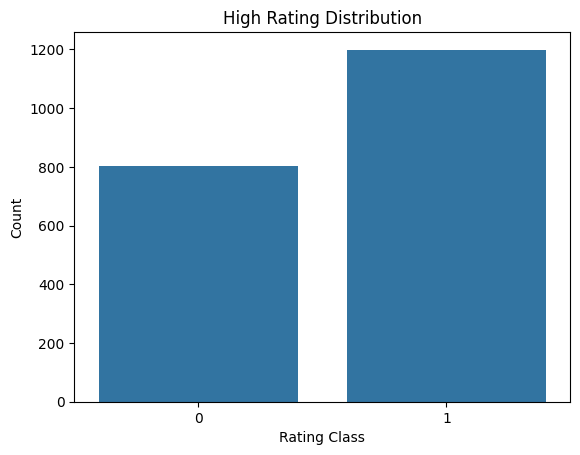

In [17]:
sns.countplot(x="High_Rating", data=df)
plt.title("High Rating Distribution")
plt.xlabel("Rating Class")
plt.ylabel("Count")
plt.show()

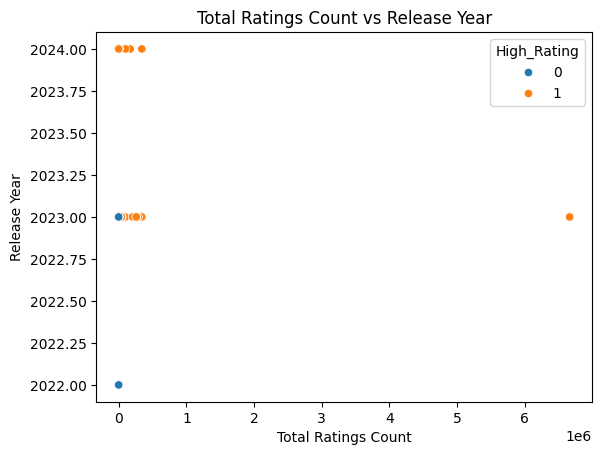

In [18]:
sns.scatterplot(data=df, x="starRating/totalRatingsCount", y="releaseYear", hue="High_Rating")
plt.title("Total Ratings Count vs Release Year")
plt.xlabel("Total Ratings Count")
plt.ylabel("Release Year")
plt.show()

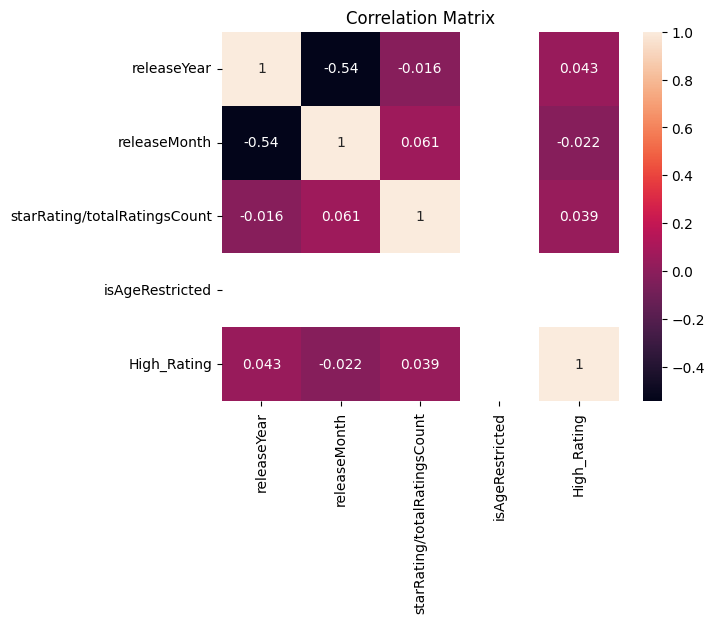

In [19]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Step 5: Split the Dataset

We divide the dataset into:

- Training Set
- Testing Set

The testing size is 20%.

In [20]:
X = df[["releaseYear", "releaseMonth", "starRating/totalRatingsCount", "isAgeRestricted"]]
y = df["High_Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 6: Feature Scaling

KNN uses distance calculations.

Feature scaling is important because it helps make the values of the predictor variables balanced.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 7: Train and Evaluate KNN Models

We will test three K values:

- K = 3
- K = 5
- K = 7

In [22]:
k_values = [3, 5, 7]

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    print("K Value:", k)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

K Value: 3
Accuracy: 0.6433915211970075
Precision: 0.6889763779527559
Recall: 0.7322175732217573
F1-score: 0.7099391480730223
Confusion Matrix:
[[ 83  79]
 [ 64 175]]

K Value: 5
Accuracy: 0.6359102244389028
Precision: 0.6809338521400778
Recall: 0.7322175732217573
F1-score: 0.7056451612903226
Confusion Matrix:
[[ 80  82]
 [ 64 175]]

K Value: 7
Accuracy: 0.628428927680798
Precision: 0.6595744680851063
Recall: 0.7782426778242678
F1-score: 0.7140115163147792
Confusion Matrix:
[[ 66  96]
 [ 53 186]]



## Step 8: Best K Value

Based on the comparison, K = 5 will be used as the best K value.

In [23]:
best_knn = KNeighborsClassifier(n_neighbors=5)
best_knn.fit(X_train_scaled, y_train)

y_pred = best_knn.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
cm

array([[ 80,  82],
       [ 64, 175]])

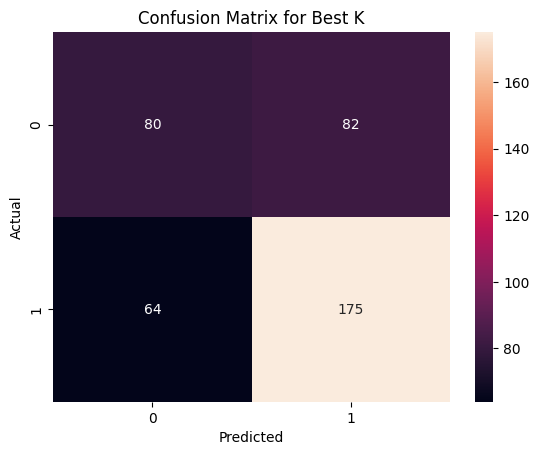

In [24]:
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix for Best K")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Interpretation of Model Results

The best-performing K value was K = 5.

This means that the model used the five nearest neighbors to classify whether a PS5 game has a high rating or low rating.

Accuracy shows the overall correct predictions of the model.

Precision shows how many predicted high-rated games were actually high-rated.

Recall shows how many actual high-rated games were correctly identified.

F1-score gives a balanced result between precision and recall.

The confusion matrix shows the correct and incorrect predictions for low-rated and high-rated PS5 games.

# Conclusion

The research question was successfully addressed because the KNN model was able to classify PS5 games into high-rating and low-rating categories.

The dataset is appropriate because it contains more than 100 rows and more than three predictor variables.

KNN was useful for this dataset because the selected features are numerical and were scaled before training.

However, the result may still depend on the quality of the selected features.

# Reflection Questions

1. The chosen dataset is appropriate for KNN classification because it contains PS5 game records and numerical predictor variables that can be used to classify games into high rating or low rating.

2. The target variable is High_Rating. It is important because it shows whether a PS5 game belongs to the high-rated or low-rated category.

3. The preprocessing challenges included converting releaseDate into date format, extracting release year and release month, converting isAgeRestricted into numeric values, checking missing values, and creating the target variable.

4. Different K values affected model performance because each K value used a different number of nearest neighbors.

5. The best-performing K value was K = 5 because it provided a balanced result based on accuracy, precision, recall, and F1-score.

6. The confusion matrix shows the correct and incorrect predictions of the model.

7. The most important metric was F1-score because it balances precision and recall.

8. There was no strong evidence of overfitting or underfitting if the model performance was reasonable and not extremely low.

9. I would recommend KNN for this dataset because it is simple, easy to understand, and works with numerical features after scaling.

10. I learned that the machine learning pipeline includes selecting a dataset, forming a research question, understanding the data, preprocessing, EDA, splitting the data, scaling, training the model, evaluating performance, and interpreting the results.